# ZQE vs R `gllvm` — Bernoulli loadings recovery

A clean, **single-dataset** playground (no sweep) for a Bernoulli GLLVM — the
binary sibling of [`../simulations/poisson.ipynb`](../simulations/poisson.ipynb).
Same idea, two differences from the Poisson notebook:

| | Poisson | **Bernoulli (here)** |
|---|---|---|
| family | `PoissonGLM` (log link) | `BinomialGLM(total_count=1)` (logit link) |
| statistic `T(y)` | `log1p(y)` | `4·(y − 0.5)` (centred; `y` already bounded) |
| encoder | Gaussian-MAP on `log1p` | Gaussian-MAP on `T` (defined inline below) |

| # | Method | Encoder | `T(y)` |
|---|--------|---------|--------|
| 1 | **ZQE — Gaussian MAP** | analytic ridge MAP on `T(y)` | `4(y−0.5)` |
| 2 | **R `gllvm` (VA)** | variational | — |

Tweak `NL, NR, NS, WZS` and the fitter knobs and re-run — everything is one cell.

In [53]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from gllvm.gllvm_module import GLLVM
from gllvm.glms import BinomialGLM
from gllvm.autofit import ZQEAutoFitter, orthogonal_align, procrustes_error
from gllvm.r_gllvm import RGllvm
from gllvm.simulations import make_mixed, simulate
from gllvm import diagnostics as dg

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)


# ---- binary ZQE statistic + Gaussian-proxy MAP encoder on that statistic ------
# (the package MapEncoderGaussianLog1p is hard-wired to log1p; for binary we want
#  the same closed-form ridge MAP but on T(y) = 4(y-0.5). Defined here so the
#  playground is self-contained.)
def T_binary(y):
    return 2.0 * (y.float() - 0.5)

class MapEncoderGaussianT(nn.Module):
    """z = (sigma2 I + WᵀW)⁻¹ Wᵀ (T(y) − b); live reference to the decoder."""
    def __init__(self, gllvm, transform=T_binary, sigma2=1.0):
        super().__init__()
        self.gllvm, self.transform, self.sigma2 = gllvm, transform, sigma2
    def forward(self, y):
        W = self.gllvm.wz
        b = (self.gllvm.bias if self.gllvm.bias is not None
             else torch.zeros(W.shape[0], device=W.device, dtype=W.dtype))
        t_y = self.transform(y).to(W.dtype)
        rhs = (t_y - b.unsqueeze(0)) @ W
        A = self.sigma2 * torch.eye(W.shape[1], device=W.device, dtype=W.dtype) + W.T @ W
        return torch.linalg.solve(A, rhs.T).T
    def sample(self, y):
        z = self.forward(y)
        return z, z, torch.full_like(z, float("-inf"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device: cuda


## Simulation

One **dense Bernoulli** GLLVM: every latent factor loads on every response.
`WZS = 0.7` keeps success probabilities nicely mixed in ~(.1, .9) — not all .5,
not saturated at 0/1. Generated on CPU so the dataset is identical on any machine.

In [ ]:
NL  = 2      # latent dimension q
NR  = 10     # responses p
NS  = 100    # observations n
WZS = 0.5    # loading scale (smaller than Poisson so probs stay unsaturated)
l2 = 0.1/NS

torch.manual_seed(12345)
g_true = make_mixed(n_latent=NL, binomial=NR, binom_trials=1, wz_scale=WZS)
Y_cpu, Z = simulate(g_true, n_samples=NS, device="cpu")
W_true = g_true.wz.detach()           # CPU; used only for scoring
Y      = Y_cpu.to(DEV)

with torch.no_grad():
    base = torch.sigmoid(g_true.bias)
    cellp = torch.sigmoid(g_true(g_true.sample_z(2000)))
print(f"p={g_true.p}  q={NL}  n={NS}   y in {{0,1}}, mean(y)={Y_cpu.mean():.3f}")
print("baseline P(y=1) quantiles:",
      [round(float(x), 2) for x in torch.quantile(base, torch.tensor([.05,.25,.5,.75,.95]))])
print(f"cells saturated (<.05 or >.95): {100*float(((cellp<.05)|(cellp>.95)).float().mean()):.1f}%")

p=10  q=2  n=100   y in {0,1}, mean(y)=0.559
baseline P(y=1) quantiles: [0.24, 0.47, 0.68, 0.74, 0.76]
cells saturated (<.05 or >.95): 1.2%


## ZQE fit

Random decoder init, no knowledge of the truth. The encoder holds a live reference
to the decoder, so it always uses the current `W, b` (it *tracks* θ).

In [55]:
def fresh_decoder():
    """Fresh dense Bernoulli decoder with ZQE statistic T(y)=4(y-0.5)."""
    g = GLLVM(latent_dim=NL, output_dim=NR, bias=True, lower_tri=True).to(DEV)
    g.add_glm(BinomialGLM, idx=list(range(NR)),
              params={"total_count": 1},
              #params={"total_count": 1, "T": T_binary},
                name="B")
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)
    return g

torch.manual_seed(SEED)
g  = fresh_decoder()
ft = ZQEAutoFitter(g, encoder_factory=lambda g: MapEncoderGaussianT(g),
                   device=DEV, seed=SEED,
                   steps_per_round=150, max_rounds=10, tol=0.001,
                   refine_lr=1, warmup_lr=.5, ema_decay=.95, verbose=False, l2=l2)
ft.fit(Y)
print(f"ZQE — Gaussian MAP   Procrustes={procrustes_error(W_true, ft.model.wz):.4f}   "
      f"change={ft.change_:.4f}   converged={ft.converged_}")

ZQE — Gaussian MAP   Procrustes=0.8391   change=0.0008   converged=True


## Diagnostics

Watch the fit behave. `plot_objective` is the headline check — the ZQE loss is the
negated empirical estimating equation, so it should **fluctuate about 0** at
convergence. (`plot_deviance` assumes a log-link Poisson, so it is skipped here.)

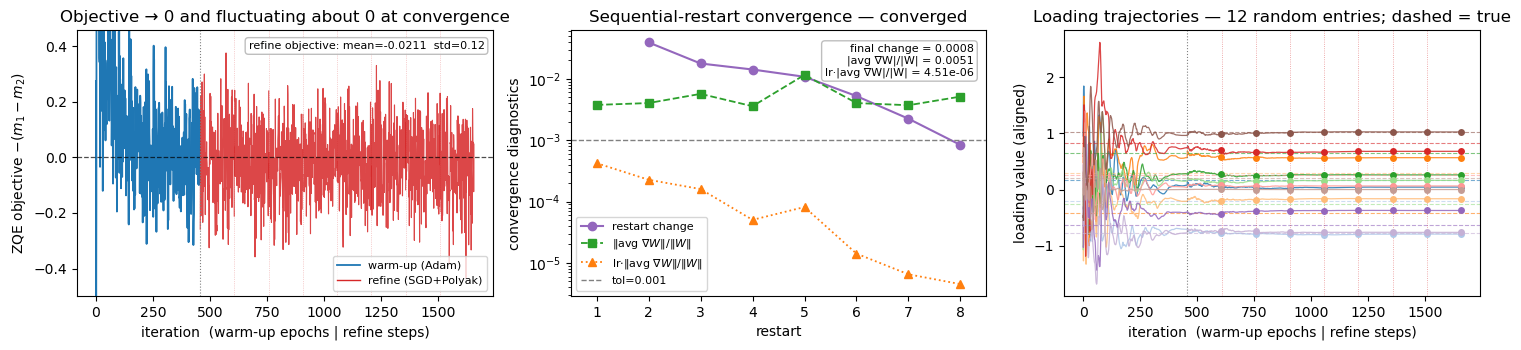

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
dg.plot_objective(ft, ax=axes[0])
dg.plot_convergence(ft, ax=axes[1])
dg.plot_params(ft, g_true=g_true, ax=axes[2])   # loadings trajectories vs dashed truth
plt.tight_layout(); plt.show()

## R `gllvm` baseline (binomial)

Its own workdir so it never clashes with the simulation sweeps. Skips cleanly if R
is unavailable.

In [57]:
r = RGllvm(method="VA", family="binomial", link="logit",
           workdir="/mnt/c/Users/willwhite/AppData/Local/Temp/r_gllvm_playground")

if r.available():
    r_fit      = r.fit(Y.cpu().numpy(), num_lv=NL, seed=SEED)
    r_loadings = r_fit.loadings
    print(f"R gllvm (VA, binomial)   Procrustes={procrustes_error(W_true, r_loadings):.4f}")
else:
    r_loadings = None
    print(f"Rscript not found at {r.rscript!r} — skipping R baseline.")

R gllvm (VA, binomial)   Procrustes=0.6839


## Results

Method                   Procrustes    Restart Δ
------------------------------------------------
ZQE — Gaussian MAP           0.8391       0.0008
R gllvm (VA)                 0.6839            —


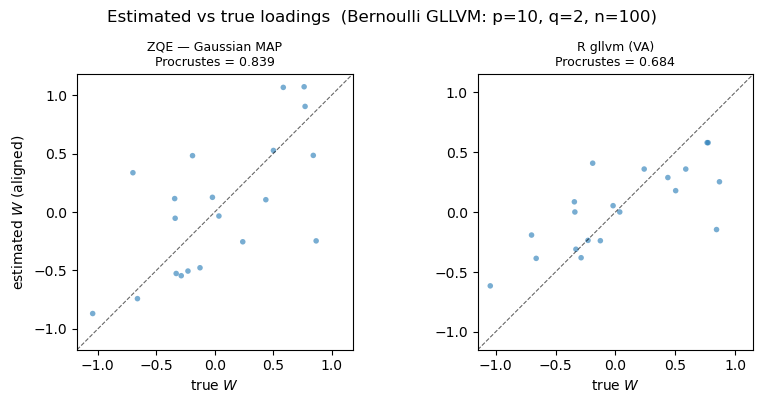

In [58]:
methods = [("ZQE — Gaussian MAP", ft.model.wz, ft.change_)]
if r_loadings is not None:
    methods.append(("R gllvm (VA)", r_loadings, float("nan")))

print(f"{'Method':<22}{'Procrustes':>13}{'Restart Δ':>13}")
print("-" * 48)
for name, W_hat, disp in methods:
    disp_str = f"{disp:.4f}" if disp == disp else "—"
    print(f"{name:<22}{procrustes_error(W_true, W_hat):>13.4f}{disp_str:>13}")


def align_to_true(W_hat):
    Wt = W_true.detach().to("cpu", torch.float64)
    We = (W_hat.detach() if isinstance(W_hat, torch.Tensor)
          else torch.as_tensor(np.asarray(W_hat))).to("cpu", torch.float64)
    return (We @ orthogonal_align(Wt, We)).numpy()

Wt_np = W_true.cpu().numpy()
fig, axes = plt.subplots(1, len(methods), figsize=(4.2 * len(methods), 4.0), squeeze=False)
fig.suptitle(f"Estimated vs true loadings  (Bernoulli GLLVM: p={NR}, q={NL}, n={NS})")
for ax, (name, W_hat, _) in zip(axes[0], methods):
    W_al = align_to_true(W_hat)
    ax.scatter(Wt_np.ravel(), W_al.ravel(), s=16, alpha=0.6, edgecolors="none")
    lim = 1.1 * max(np.abs(Wt_np).max(), np.abs(W_al).max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.6)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.set_title(f"{name}\nProcrustes = {procrustes_error(W_true, W_hat):.3f}", fontsize=9)
    ax.set_xlabel("true $W$")
axes[0][0].set_ylabel("estimated $W$ (aligned)")
plt.tight_layout(); plt.show()